In [ ]:
!pwd
!unzip '/content/drive/MyDrive/Colab Notebooks/tyne/data/carpet.zip' -d /content/

# Stage-one inference

Loaded Memory Bank Shape: (2240, 1536)


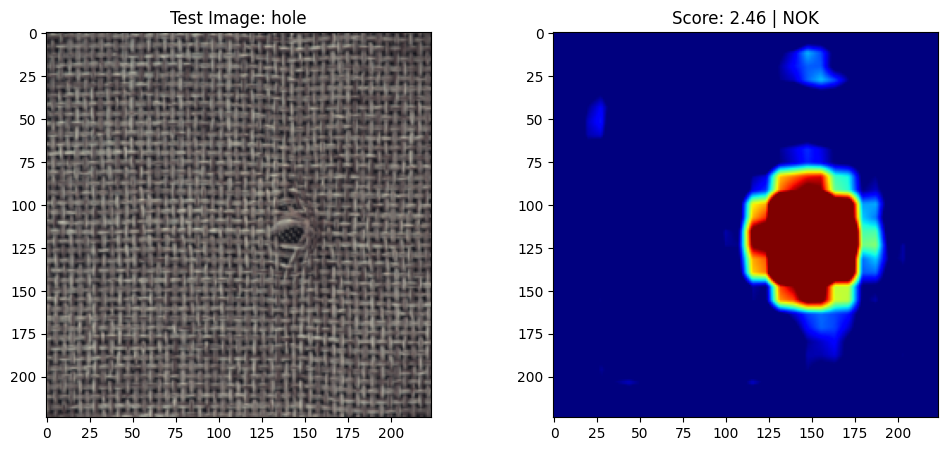


Validation check on carpet/test/hole/007.png:
Max Anomaly Score: 27.4969
Threshold: 11.1805


In [ ]:
!pip install onnxruntime

import onnxruntime as ort
import numpy as np
import torch
import faiss
import matplotlib.pyplot as plt
from PIL import Image

# 1. Load the Memory Bank from .npy
loaded_memory_bank = np.load("memory_bank.npy").astype('float32')
print(f"Loaded Memory Bank Shape: {loaded_memory_bank.shape}")

# 2. Re-initialize FAISS index with loaded data
dim = loaded_memory_bank.shape[1]
validation_index = faiss.IndexFlatL2(dim)
validation_index.add(loaded_memory_bank)

# 3. Load the ONNX model
ort_session = ort.InferenceSession("resnet_backbone.onnx", providers=['CPUExecutionProvider'])

def get_onnx_features(img_path):
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).numpy()

    ort_inputs = {ort_session.get_inputs()[0].name: img_tensor}
    ort_outs = ort_session.run(None, ort_inputs)
    return img_tensor, ort_outs[0].astype('float32')

# 4. Validation Inference & Heatmap Generation
test_img_path = 'carpet/test/hole/007.png'
original_img_np, onnx_features = get_onnx_features(test_img_path)

# Search loaded FAISS index
distances, _ = validation_index.search(onnx_features, 1)
dist_score = np.sqrt(distances)
anomaly_score = np.max(dist_score)

# Reshape and upscale the heatmap (28x28 based on backbone architecture)
segm_map = torch.from_numpy(dist_score).view(1, 1, 28, 28)
segm_map = torch.nn.functional.interpolate(
    segm_map,
    size=(224, 224),
    mode='bilinear'
).squeeze().numpy()

# Visualization
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(original_img_np.squeeze().transpose(1, 2, 0))
plt.title(f'Test Image: {test_img_path.split("/")[-2]}')

plt.subplot(1, 2, 2)
plt.imshow(segm_map, cmap='jet', vmin=best_threshold * 0.8, vmax=best_threshold * 1.2)
plt.title(f'Score: {anomaly_score/best_threshold:.2f} | {"NOK" if anomaly_score >= best_threshold else "OK"}')
plt.show()

print(f"\nValidation check on {test_img_path}:")
print(f"Max Anomaly Score: {anomaly_score:.4f}")
print(f"Threshold: {best_threshold:.4f}")

# Stage-two inference ResNet50 version


[CUDA] 載入 ResNet50(Layer2+3)特徵提取器...
找到 89 張完整影像, 真實瑕疵類別: ['color', 'cut', 'hole', 'metal_contamination', 'thread']
使用 200 / 280 張正常影像建立原型


抽取特徵+描述子 (mode=both): 100%|██████████| 89/89 [00:11<00:00,  7.51it/s]
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


特徵維度  deep=1536  color=5  shape=5
第一層 PCA 後維度: 70

第二層: 切最均衡雙峰的 cluster1(n=31) -> cluster4(n=13), ecc差=0.362, 少數佔比=42%

 Clustering Benchmark (第一層 = v2 deep+color+shape)
 樣本數 N / 真實類別數 K : 89 / 5
 分出 cluster 數         : 4
 noise / Coverage        : 0 (0.0%) / 100.0%
   ARI=0.625  AMI=0.703  NMI=0.717  V-measure=0.717  FMI=0.717
   Homogeneity=0.659  Completeness=0.786
   Purity(加權)=0.753   Hungarian 準確率=0.753
   [Internal/PCA] Silhouette=+0.115  Davies-Bouldin=2.427  Calinski-Harabasz=8.2

 [Contingency  cluster(列) × 真實瑕疵類別(欄)]
          color  cut  hole  metal_contamination  thread                 主要類別    純度
cluster0     19    2     1                    0       3                color  0.76
cluster1      0   14    16                    0       1                 hole  0.52
cluster2      0    0     0                   17       0  metal_contamination  1.00
cluster3      0    1     0                    0      15               thread  0.94

 Clustering Benchmark (最終 + shape 補切 cut/hole)
 樣本

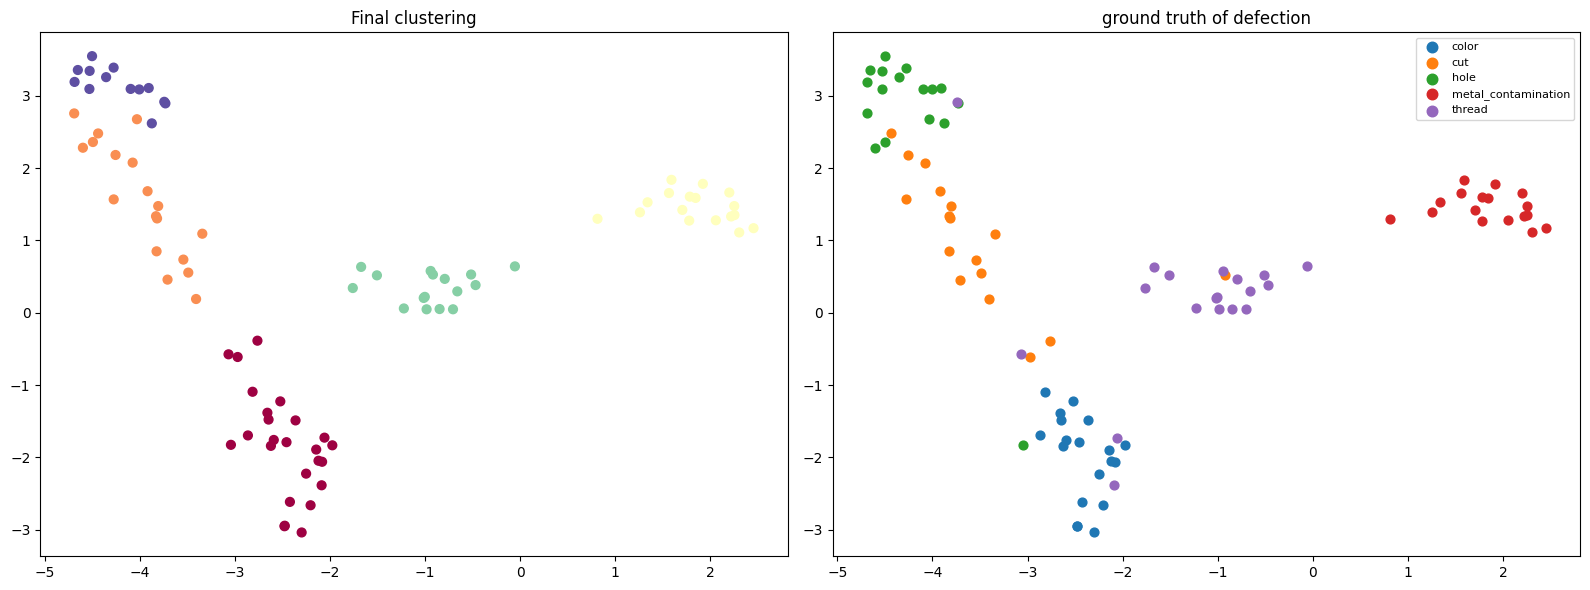

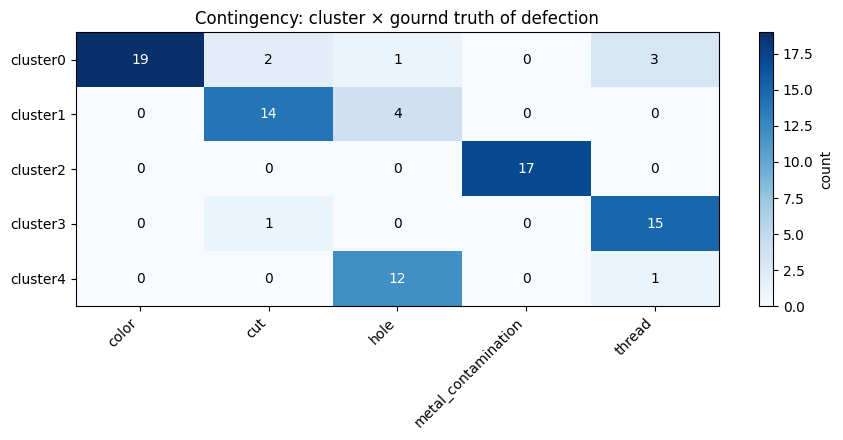


正在將圖片分類至各 cluster 資料夾...

=== 分群統計 ===
cluster0: 25 張
cluster1: 18 張
cluster2: 17 張
cluster3: 16 張
cluster4: 13 張


In [ ]:
"""
Stage-2 Clustering (階層式分群 v2: 以 v2(0.75) 為第一層, 第二層只補一刀切 cut/hole)
================================================================================
上一版階層式分群的錯誤: 第一層只用 deep+color, 結果 color/cut/hole/thread 全糊成一團
—— 因為 v2 裡的 shape 區塊不只分 cut/hole, 也在幫 color 站出來, 抽掉它等於拆承重牆。

修正:
  第一層 = 完整 v2 配置 (deep + color + shape, 權重 1.0/0.3/0.3)
           -> 可分成乾淨群: color / metal / thread + (cut+hole 合併)。
  第二層 = 只對「ecc 雙峰」的群 (=cut+hole 混群) 補一刀, 用 KMeans(2) 沿 shape 切開。
           兩道保險 (ecc 差夠大 + 群內 ecc 夠分散) 確保 metal/thread/color 不被誤切。

★資料夾 (MVTec 標準結構):
   IMAGE_DIR  = .../carpet/test/test/<defecttype>/*.png
   NORMAL_DIR = .../carpet/train/good/
"""

import os
import glob
import random
import shutil

import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms, models
from torchvision.models.feature_extraction import create_feature_extractor
from tqdm import tqdm


from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    adjusted_mutual_info_score,
    normalized_mutual_info_score,
    homogeneity_completeness_v_measure,
    fowlkes_mallows_score,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)
from scipy.optimize import linear_sum_assignment
from scipy import ndimage as ndi
from skimage import measure
import pandas as pd
import matplotlib.pyplot as plt

import umap
import hdbscan

# ==========================================
# 0. 設定
# ==========================================
IMAGE_DIR   = "/content/carpet/test/"
NORMAL_DIR  = "/content/carpet/train/good/"
INCLUDE_GOOD = False
INPUT_SIZE   = 448
FEATURE_MODE = "both"
MAX_NORMAL   = 200
WEIGHT_POWER = 3.0

# --- 描述子: 緊致定位 ---
SMOOTH_SIGMA = 4.0
MASK_K       = 3.0
MASK_PCTL    = 97.5
BG_PCTL      = 50

# --- 第一層: deep + color + shape (= v2 配置, 產生乾淨 4 群含 cut+hole 合併) ---
W_DEEP  = 1.0
W_COLOR = 0.3
W_SHAPE = 0.3
MIN_CLUSTER_SIZE = 3

# --- 第二層: 只切「一分為二最均衡」的群 (cut+hole); 靠均衡度區分『真雙峰 vs 有離群點』 ---
SPLIT_ECC_GAP = 0.25         # 兩子群平均 ecc 差 >= 此值 (cut vs hole ~0.3+)
BALANCE_FRAC  = 0.30         # 少數子群需 >= 群大小的此比例 (cut+hole ~0.47; color 甩離群點 ~0.18 被擋)
MIN_SUB       = 4

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[{device.upper()}] 載入 ResNet50(Layer2+3)特徵提取器...")

# ==========================================
# 1. 特徵提取器
# ==========================================
base_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT).to(device)
feature_extractor = create_feature_extractor(base_model, {"layer2": "layer2", "layer3": "layer3"})
feature_extractor.eval()

transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
LAYERS = ["layer2", "layer3"]


def extract_maps(img):
    img_t = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        out = feature_extractor(img_t)
    return {L: out[L][0] for L in LAYERS}


# ==========================================
# 2. 讀取完整瑕疵影像
# ==========================================
image_paths, ground_truth_labels = [], []
for p in sorted(glob.glob(os.path.join(IMAGE_DIR, "**", "*"), recursive=True)):
    if not p.lower().endswith( (".png", ".jpg", ".jpeg") ):
        continue
    label = os.path.basename(os.path.dirname(p))
    if label == "good" and not INCLUDE_GOOD:
        continue
    image_paths.append(p)
    ground_truth_labels.append(label)

unique_labels = sorted(set(ground_truth_labels))
print(f"找到 {len(image_paths)} 張完整影像, 真實瑕疵類別: {unique_labels}")

# ==========================================
# 3. 正常織紋原型
# ==========================================

def build_prototype(sources, max_n):
    stats = {L: {"sum": 0.0, "sqsum": 0.0, "n": 0} for L in LAYERS}
    for p in tqdm(sources[:max_n], desc="估計正常織紋原型"):
        maps = extract_maps(Image.open(p).convert("RGB"))

        for L in LAYERS:
            v = maps[L].reshape(maps[L].shape[0], -1).T
            stats[L]["sum"]   += v.sum(0)
            stats[L]["sqsum"] += (v * v).sum(0)
            stats[L]["n"]     += v.shape[0]

    proto = {}
    for L in LAYERS:
        cnt = stats[L]["n"]
        mu = stats[L]["sum"] / cnt
        var = stats[L]["sqsum"] / cnt - mu * mu
        proto[L] = (mu, torch.sqrt(torch.clamp(var, min=1e-6)))
    return proto


normal_paths = []
if NORMAL_DIR and os.path.isdir(NORMAL_DIR):
    normal_paths = sorted(p for p in glob.glob(os.path.join(NORMAL_DIR, "**", "*"), recursive=True)
                          if p.lower().endswith( (".png", ".jpg", ".jpeg") ))
if normal_paths:
    print(f"使用 {min(len(normal_paths), MAX_NORMAL)} / {len(normal_paths)} 張正常影像建立原型")
    prototype = build_prototype(normal_paths, MAX_NORMAL)
else:
    print("⚠ 找不到 NORMAL_DIR -> 退回用『所有瑕疵影像的平均』當原型")
    prototype = build_prototype(image_paths, len(image_paths))

# ==========================================
# 4. 特徵抽取: 深度特徵 + 緊致 anomaly map + 殘差色彩/形狀 (v2 描述子)
# ==========================================

def defect_mask(amap):
    """
    從 anomaly map 中精確定位瑕疵區域 (Mask)。
    運作邏輯：
    1. 高斯平滑：濾除背景細微織紋雜訊。
    2. 動態門檻：結合 (mean + K*std) 與 (高百分位) 確保 mask 緊貼瑕疵核心。
    3. 利用全域最高分點 (peak) 定位主要瑕疵，排除邊緣誤報。
    """
    a = ndi.gaussian_filter(amap, sigma=SMOOTH_SIGMA)
    thr = max(a.mean() + MASK_K * a.std(), np.percentile(a, MASK_PCTL))
    m = a >= thr
    if m.sum() < 4:
        m = a >= np.percentile(a, 99)
    m = ndi.binary_closing(m, iterations=1)
    lbl = measure.label(m)
    if lbl.max() == 0:
        return m, a
    peak = np.unravel_index(np.argmax(a), a.shape)
    peak_label = lbl[peak]
    if peak_label == 0:
        counts = np.bincount(lbl.ravel())
        peak_label = int(np.argmax(counts[1:])) + 1
    return (lbl == peak_label), a


def color_descriptor(rgb, amap, mask):
    """殘差色彩 5 維: 殘差RGB(3) + 亮度殘差(1) + 瑕疵飽和度(1)。"""
    bg = amap <= np.percentile(amap, BG_PCTL)
    if mask.sum() < 3:
        mask = amap >= np.percentile(amap, 99)
    if bg.sum() < 10:
        bg = ~mask
    d, b = rgb[mask], rgb[bg]
    res_rgb = d.mean(0) - b.mean(0)
    res_bright = np.array([d.mean(1).mean() - b.mean(1).mean()])
    sat = (d.max(1) - d.min(1)).mean()
    return np.concatenate([res_rgb, res_bright, [sat]]).astype(np.float32)


def shape_descriptor(mask):
    """
      skimage.measure提供連通區域標記、形狀屬性計算、輪廓提取及影像矩等功能
      v2 形狀 5 維: area / ecc / solidity / extent / aspect  (ecc 在 index 1)。
    """
    default = np.array([0.0, 0.0, 1.0, 1.0, 1.0], dtype=np.float32)
    try:
        lbl = measure.label(mask)
        props = measure.regionprops(lbl)
        if not props:
            return default
        r = max(props, key=lambda p: p.area)
        if r.area < 4:
            return default
        minr, minc, maxr, maxc = r.bbox
        h, w = (maxr - minr), (maxc - minc)
        aspect = max(h, w) / (min(h, w) + 1e-6)
        return np.array([r.area / mask.size, r.eccentricity,
                         r.solidity, r.extent, aspect], dtype=np.float32)
    except Exception:
        return default


def extract_features(img):
    rgb = np.asarray(img.resize((INPUT_SIZE, INPUT_SIZE), Image.BILINEAR).convert("RGB"),
                     dtype=np.float32) / 255.0
    maps = extract_maps(img)
    deep_vecs, score_maps = [], []
    for L in LAYERS:
        m = maps[L]
        C, H, W = m.shape
        f = m.reshape(C, -1)
        mu, std = prototype[L]
        fz = (f - mu[:, None]) / std[:, None]
        score = fz.norm(dim=0)
        w = score.pow(WEIGHT_POWER)
        w = w / (w.sum() + 1e-8)
        weighted = (f * w[None, :]).sum(1)
        if FEATURE_MODE == "weighted":
            vec = weighted
        elif FEATURE_MODE == "residual":
            vec = f.mean(1) - mu
        else:
            vec = weighted - mu
        deep_vecs.append(vec)
        sm = score.reshape(H, W).float()
        sm = (sm - sm.min()) / (sm.max() - sm.min() + 1e-8)
        sm = F.interpolate(sm[None, None], size=(INPUT_SIZE, INPUT_SIZE), mode="bilinear", align_corners=False)[0, 0]
        score_maps.append(sm)
    deep = torch.cat(deep_vecs).cpu().numpy()
    amap = torch.stack(score_maps).mean(0).cpu().numpy()
    mask, amap_s = defect_mask(amap)
    return deep, color_descriptor(rgb, amap_s, mask), shape_descriptor(mask)


deep_list, color_list, shape_list = [], [], []
for img_path in tqdm(image_paths, desc=f"抽取特徵+描述子 (mode={FEATURE_MODE})"):
    d, c, s = extract_features(Image.open(img_path).convert("RGB"))
    deep_list.append(d); color_list.append(c); shape_list.append(s)

deep_all  = np.asarray(deep_list)
color_all = np.asarray(color_list)
shape_all = np.asarray(shape_list)     # 5 維; ecc = [:,1]
print(f"特徵維度  deep={deep_all.shape[1]}  color={color_all.shape[1]}  shape={shape_all.shape[1]}")

# ==========================================
# 5. 第一層: deep + color + shape (= v2), 產生乾淨 4 群
# ==========================================

def block_prep(X, weight):
    """
    對特徵塊 X 進行標準化並按其維度與目標權重進行縮放。
    StandardScaler 確保特徵通道具有統一尺度，
    除以 sqrt(維度) 則是為了平衡高維 (如 deep) 與低維 (如 color) 特徵的影響力。
    """
    Xs = StandardScaler().fit_transform(X) # 把每個通道的平均值為 0，標準差為 1
    return Xs * (weight / np.sqrt(X.shape[1])) # 最後乘上 weight（權重）, 讓 color 和 shape 的特徵重要度提升, 不會被本身 deep 的特徵淹沒

# 將三種特徵依據權重拼接起來
feat_L1 = np.concatenate([block_prep(deep_all,  W_DEEP),
                          block_prep(color_all, W_COLOR),
                          block_prep(shape_all, W_SHAPE)], axis=1)

# 全域 L2 正規化：將向量縮放為單位長度。
# 註：這使得後續 PCA 降維與 UMAP 運算的歐式空間實際上是在處理「餘弦相似度 (Cosine Similarity)」。
feat_L1 = normalize(feat_L1, norm="l2")

pca = PCA(n_components=0.95, random_state=SEED)
pca_L1 = pca.fit_transform(feat_L1)
print(f"第一層 PCA 後維度: {pca_L1.shape[1]}")

umap_L1 = umap.UMAP(n_neighbors=15, n_components=2, min_dist=0.0,
                    random_state=SEED, metric="cosine").fit_transform(pca_L1)
labels_L1 = hdbscan.HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE).fit_predict(umap_L1)

# ==========================================
# 6. 第二層: 只切「ecc 雙峰」的群 (cut+hole)
# ==========================================

def refine_by_shape(labels, shape_all):
    """
    此函式用於執行『二階段分群』中的形狀補刀機制。
    它的作用是從第一層的分群結果中，找出可能同時包含 cut 與 hole 的混合群集，
    並利用離心率 (Eccentricity) 將其切開。

    運作邏輯：
    1. 提取所有樣本的 ecc (離心率) 特徵。
    2. 遍歷現有的每一個第一次分群的 Cluster，嘗試用 KMeans(2) 將其分成兩個子群。
    3. 因為已知cut/hole的瑕疵最大的差異是形狀(長條狀的割線和較集中的破損), 在經過ecc的幾何特徵的加入,
      理論上會有一個cluster的可以明顯的切分出兩個sub-cluster, 依此來判斷：
       - 兩群平均 ecc 差距須夠大 (由 SPLIT_ECC_GAP 控制)。
       - 兩群樣本數須相對均衡 (由 BALANCE_FRAC 控制)，避免只是切掉少數離群點。
    4. 若符合條件，則執行切分並將其中一部分標記為新的 Cluster ID, 從而再把原本ResNet50無法明確區隔的瑕疵特徵做分別
    """
    ecc = shape_all[:, 1]                      # v2 shape 的 ecc 在 index 1
    new = labels.copy()

    candidates = []
    for k in sorted(set(labels)):
        if k == -1:
            continue
        idx = np.where(labels == k)[0]
        if len(idx) < 2 * MIN_SUB:
            continue
        km = KMeans(n_clusters=2, n_init=10, random_state=SEED).fit(ecc[idx].reshape(-1, 1))
        a, b = idx[km.labels_ == 0], idx[km.labels_ == 1]
        nmin = min(len(a), len(b))
        gap = abs(ecc[a].mean() - ecc[b].mean())
        # 需同時: 兩子群 ecc 差夠大, 且切分夠均衡(不是只甩幾個離群點)
        if gap >= SPLIT_ECC_GAP and nmin >= max(MIN_SUB, BALANCE_FRAC * len(idx)):
            candidates.append((nmin, gap, k, idx, a, b))

    if not candidates:
        print(f"\n第二層: 無群同時滿足 ecc差>={SPLIT_ECC_GAP} 且 均衡度>={BALANCE_FRAC} -> 不切")
        return new

    # 在合格候選裡, 選「均衡切分規模最大」的 -> 真正一分為二的 cut+hole
    nmin, gap, k, idx, a, b = max(candidates, key=lambda t: t[0])
    minor = a if len(a) < len(b) else b
    next_id = int(labels.max()) + 1
    new[minor] = next_id
    print(f"\n第二層: 切最均衡雙峰的 cluster{k}(n={len(idx)}) -> "
          f"cluster{next_id}(n={len(minor)}), ecc差={gap:.3f}, 少數佔比={nmin/len(idx):.0%}")
    return new


labels_final = refine_by_shape(labels_L1, shape_all)

# ==========================================
# 7. Clustering Benchmark (第一層 vs 最終)
# ==========================================
gt = np.array([unique_labels.index(l) for l in ground_truth_labels])


def clustering_benchmark(cluster_labels, gt, unique_labels, space_pca, tag=""):
    non_noise = cluster_labels != -1
    labels_c = cluster_labels[non_noise]
    labels_t = gt[non_noise]
    n_true = len(unique_labels)
    cl_ids = sorted(set(labels_c))
    n_pred = len(cl_ids)

    print("\n" + "=" * 56)
    print(f" Clustering Benchmark {tag}")
    print("=" * 56)
    print(f" 樣本數 N / 真實類別數 K : {len(cluster_labels)} / {n_true}")
    print(f" 分出 cluster 數         : {n_pred}")
    print(f" noise / Coverage        : {int((~non_noise).sum())} ({np.mean(~non_noise):.1%}) / {np.mean(non_noise):.1%}")
    if non_noise.sum() < 2 or n_pred < 1:
        print(" 有效分群點過少, 略過。")
        return None

    ari = adjusted_rand_score(labels_t, labels_c)
    ami = adjusted_mutual_info_score(labels_t, labels_c)
    nmi = normalized_mutual_info_score(labels_t, labels_c)
    homo, comp, vmea = homogeneity_completeness_v_measure(labels_t, labels_c)
    fmi = fowlkes_mallows_score(labels_t, labels_c)

    cm = np.zeros((n_pred, n_true), dtype=int)
    for a, k in enumerate(cl_ids):
        for t in range(n_true):
            cm[a, t] = np.sum((labels_c == k) & (labels_t == t))
    purity = cm.max(axis=1).sum() / len(labels_c)
    row, col = linear_sum_assignment(-cm)
    hung_acc = cm[row, col].sum() / len(labels_c)

    print(f"   ARI={ari:.3f}  AMI={ami:.3f}  NMI={nmi:.3f}  V-measure={vmea:.3f}  FMI={fmi:.3f}")
    print(f"   Homogeneity={homo:.3f}  Completeness={comp:.3f}")
    print(f"   Purity(加權)={purity:.3f}   Hungarian 準確率={hung_acc:.3f}")
    if n_pred >= 2:
        try:
            sil = silhouette_score(space_pca[non_noise], labels_c)
            db = davies_bouldin_score(space_pca[non_noise], labels_c)
            ch = calinski_harabasz_score(space_pca[non_noise], labels_c)
            print(f"   [Internal/PCA] Silhouette={sil:+.3f}  Davies-Bouldin={db:.3f}  Calinski-Harabasz={ch:.1f}")
        except ValueError as e:
            print(f"   [Internal] 略過 ({e})")

    df = pd.DataFrame(cm, index=[f"cluster{k}" for k in cl_ids], columns=unique_labels)
    df["主要類別"] = df[unique_labels].idxmax(axis=1)
    df["純度"] = (cm.max(axis=1) / cm.sum(axis=1)).round(2)
    print("\n [Contingency  cluster(列) × 真實瑕疵類別(欄)]")
    print(df.to_string())
    return df


clustering_benchmark(labels_L1, gt, unique_labels, pca_L1, tag="(第一層 = v2 deep+color+shape)")
benchmark_df = clustering_benchmark(labels_final, gt, unique_labels, pca_L1, tag="(最終 + shape 補切 cut/hole)")

# ==========================================
# 8. 可視化
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].scatter(umap_L1[:, 0], umap_L1[:, 1], c=labels_final, cmap="Spectral", s=40)
axes[0].set_title("Final clustering")
for li, lab in enumerate(unique_labels):
    m = gt == li
    axes[1].scatter(umap_L1[m, 0], umap_L1[m, 1], s=40, label=lab)
axes[1].set_title("ground truth of defection")
axes[1].legend(markerscale=1.2, fontsize=8)
plt.tight_layout()
plt.savefig("/content/cluster_vs_gt.png", dpi=120)
plt.show()

if benchmark_df is not None:
    cm = benchmark_df[unique_labels].values
    fig, ax = plt.subplots(figsize=(1.4 * len(unique_labels) + 2, 0.5 * cm.shape[0] + 2))
    im = ax.imshow(cm, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(unique_labels)), unique_labels, rotation=45, ha="right")
    ax.set_yticks(range(cm.shape[0]), list(benchmark_df.index))
    for r in range(cm.shape[0]):
        for c in range(cm.shape[1]):
            ax.text(c, r, cm[r, c], ha="center", va="center",
                    color="white" if cm[r, c] > cm.max() / 2 else "black")
    ax.set_title("Contingency: cluster × gournd truth of defection")
    fig.colorbar(im, ax=ax, label="count")
    plt.tight_layout()
    plt.savefig("/content/benchmark_contingency.png", dpi=120)
    plt.show()

# ==========================================
# 9. 依 cluster 分類存放圖片
# ==========================================
print("\n正在將圖片分類至各 cluster 資料夾...")
for i, label in enumerate(labels_final):
    folder = f"cluster{label}" if label != -1 else "noise"
    target_dir = os.path.join("/content", folder)
    os.makedirs(target_dir, exist_ok=True)
    dst_name = f"{ground_truth_labels[i]}_{os.path.basename(image_paths[i])}"
    shutil.copy(image_paths[i], os.path.join(target_dir, dst_name))

print("\n=== 分群統計 ===")
for k in np.unique(labels_final):
    name = f"cluster{k}" if k != -1 else "noise"
    print(f"{name}: {int(np.sum(labels_final == k))} 張")


# Stage-two inference DINOv2 version

[CUDA] 載入 DINOv2 (dinov2_vitb14_reg) ... INPUT_SIZE=448 -> patch grid 32x32
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_reg4_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_reg4_pretrain.pth


100%|██████████| 330M/330M [00:01<00:00, 220MB/s]


DINOv2 dinov2_vitb14_reg · embed_dim=768 · 共 12 個 block · 使用中間層 [3, 5]
找到 89 張完整影像, 真實瑕疵類別: ['color', 'cut', 'hole', 'metal_contamination', 'thread']
使用 200 / 280 張正常影像建立記憶庫


建立正常特徵記憶庫: 100%|██████████| 200/200 [00:25<00:00,  7.95it/s]


  blk3: 記憶庫 20000 patches × 768D
  blk5: 記憶庫 20000 patches × 768D


抽取 deep(餘弦)+color+shape+elong (power=3.0, K=1): 100%|██████████| 89/89 [00:17<00:00,  5.18it/s]
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


特徵維度  deep=1536  color=5  shape=5  elong範圍=[1.01,21.41]
KernelPCA(cosine) 後維度: 20 / 原始 1541  (W_DEEP=1.0, W_COLOR=0.3)

第二層: 切低色差幾何 blob cluster0(n=34, 色強度=0.057) -> cluster4(n=14, 偏低ecc(hole)), ecc差=0.258, 少數佔比=41%

 Clustering Benchmark (第一層 餘弦評分 = DINOv2 dinov2_vitb14_reg deep+color · power=3.0, K=1)
 樣本數 N / 真實類別數 K : 89 / 5
 分出 cluster 數         : 4
 noise / Coverage        : 2 (2.2%) / 97.8%
   ARI=0.610  AMI=0.734  NMI=0.748  V-measure=0.748  FMI=0.713
   Homogeneity=0.676  Completeness=0.839
   Purity(加權)=0.724   Hungarian 準確率=0.724
   [Internal/PCA] Silhouette=+0.185  Davies-Bouldin=1.855  Calinski-Harabasz=14.8

 [Contingency  cluster(列) × 真實瑕疵類別(欄)]
          color  cut  hole  metal_contamination  thread                 主要類別    純度
cluster0      0   17    16                    0       1                  cut  0.50
cluster1     19    0     1                    0       6                color  0.73
cluster2      0    0     0                   17       0  metal_contamination  1.00

/tmp/ipykernel_550/1810314425.py:452: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_550/1810314425.py:452: UserWarning: Glyph 32066 (\N{CJK UNIFIED IDEOGRAPH-7D42}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_550/1810314425.py:452: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_550/1810314425.py:452: UserWarning: Glyph 32676 (\N{CJK UNIFIED IDEOGRAPH-7FA4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_550/1810314425.py:452: UserWarning: Glyph 31532 (\N{CJK UNIFIED IDEOGRAPH-7B2C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_550/1810314425.py:452: UserWarning: Glyph 20108 (\N{CJK UNIFIED IDEOGRAPH-4E8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_550/1810314425.py:452: UserWarning: Glyph 23652 (\N{CJK UNIFIED IDEOGRAPH-5C64}

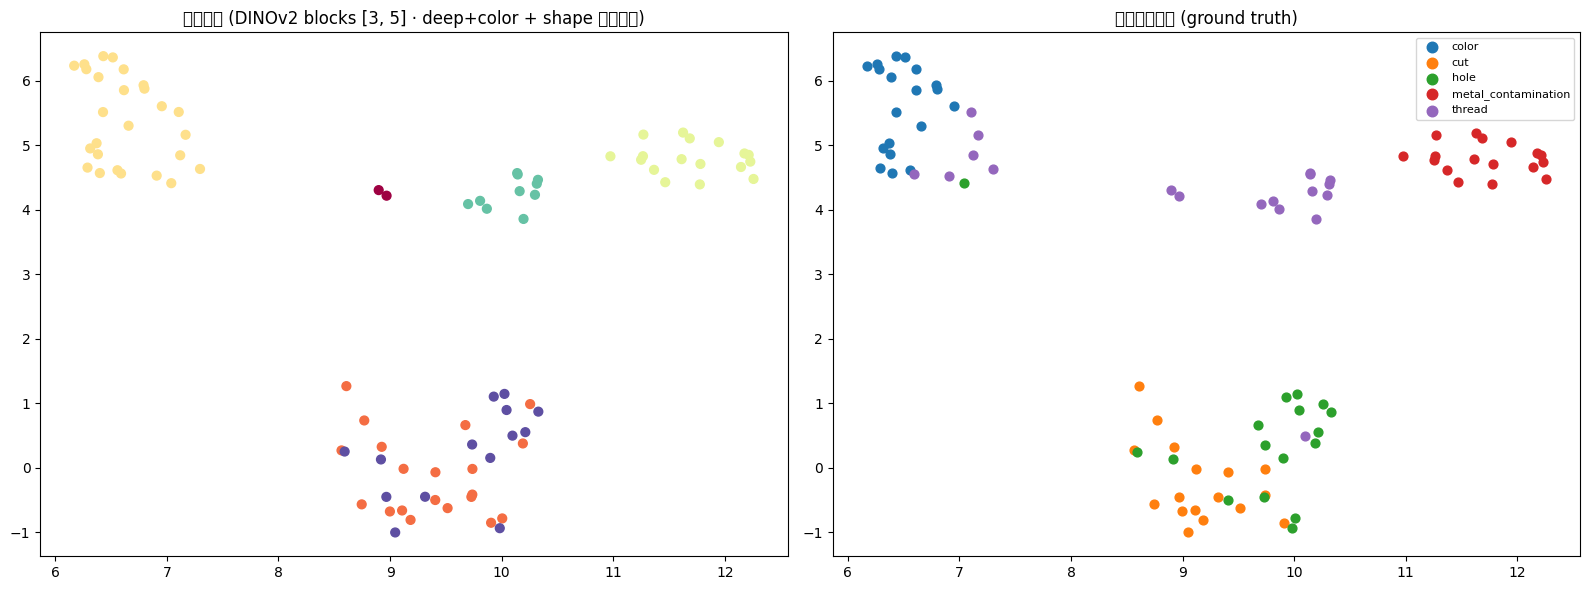

/tmp/ipykernel_550/1810314425.py:468: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_550/1810314425.py:468: UserWarning: Glyph 23526 (\N{CJK UNIFIED IDEOGRAPH-5BE6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_550/1810314425.py:468: UserWarning: Glyph 29781 (\N{CJK UNIFIED IDEOGRAPH-7455}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_550/1810314425.py:468: UserWarning: Glyph 30133 (\N{CJK UNIFIED IDEOGRAPH-75B5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_550/1810314425.py:468: UserWarning: Glyph 39006 (\N{CJK UNIFIED IDEOGRAPH-985E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_550/1810314425.py:468: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_550/1810314425.py:468: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}

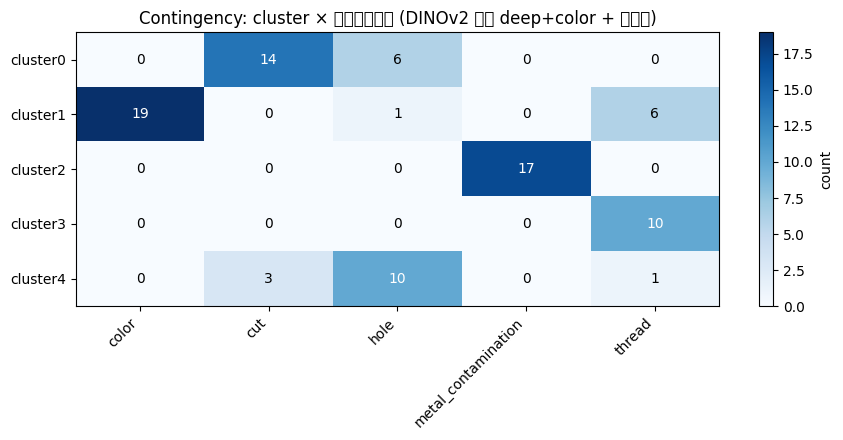


正在將圖片分類至各 cluster 資料夾...

=== 分群統計 ===
noise: 2 張
cluster0: 20 張
cluster1: 26 張
cluster2: 17 張
cluster3: 10 張
cluster4: 14 張


In [ ]:
"""
Stage-2 Clustering — DINOv2 餘弦最近鄰異常評分 (丟掉歐式殘差) + deep+color + 第二層 (ABLATION 第 5 步)
================================================================================
前四步用『歐式 z-score 殘差』當異常評分, Hungarian 卡在 0.494(且 448/784 皆同 -> 解析度非瓶頸)。
本步改用『餘弦相似度』發揮 DINOv2 特徵優勢:

  異常評分:  ‖(f−μ)/σ‖ (歐式 z-score)   ->   1 − 對正常記憶庫的最近鄰餘弦相似度
  deep 特徵: weighted − μ (歐式殘差)      ->   L2-normalize(餘弦異常加權池化)

為何餘弦更對味: DINOv2 是 LayerNorm 特徵, 語意編碼在『方向』而非『逐通道幅度』; 餘弦/最近鄰記憶庫
(PatchCore / AnomalyDINO 式)比『對單一 mean 的逐通道 z-score』更貼其幾何, 且記憶庫保留正常織紋
的多樣性(多峰), 不會把多樣正常壓成一個 mean。

其餘沿用第 4 步: 第一層 deep+color(block_prep 平衡 1.0/0.3)-> HDBSCAN; 第二層切 cut/hole
(★色強度排除 color/metal, 再用 ecc 分 cut/hole; 伸長率版試過第二層不切故回 ecc)。
color/shape 一樣吃 anomaly map 定位, 只是 map 改由餘弦分數產生(定位可能更準)。

★資料夾假設 (MVTec 標準結構):
   IMAGE_DIR  = .../carpet/test/          test/<defecttype>/*.png  (標籤=上層資料夾名)
   NORMAL_DIR = .../carpet/train/good/    正常影像, 建立記憶庫
"""

import os
import glob
import random
import shutil

import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
from tqdm import tqdm

from sklearn.decomposition import PCA, KernelPCA
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.cluster import KMeans   # 第二層 1D-ecc 切刀用
from sklearn.metrics import (
    adjusted_rand_score,
    adjusted_mutual_info_score,
    normalized_mutual_info_score,
    homogeneity_completeness_v_measure,
    fowlkes_mallows_score,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)
from scipy.optimize import linear_sum_assignment
from scipy import ndimage as ndi
from skimage import measure
import pandas as pd
import matplotlib.pyplot as plt

import umap
import hdbscan

# ==========================================
# 0. 設定
# ==========================================
IMAGE_DIR    = "/content/carpet/test/"
NORMAL_DIR   = "/content/carpet/train/good/"   # 建立正常織紋原型; 找不到則退回用全部瑕疵圖的平均
INCLUDE_GOOD = False

DINO_MODEL   = "dinov2_vitb14_reg"   # vits14/vitb14/vitl14/vitg14 (+_reg); 失敗改不帶 _reg
DINO_LAYERS  = [3, 5]                # ★定案。[3,5,8] 重測(改造第二層)= 0.708 < 0.753: 其 cut/hole
#   ecc 分不開、第二層安全不切、hole 丟失。[3,5] 的 cut/hole 切得開 -> 0.753 為最佳。
PATCH        = 14
INPUT_SIZE   = 448                   # 14 的倍數 -> 32x32 patch grid。★餘弦版最佳解就是 448(0.753);
#   試過 784(56x56)反而更差(0.627, 細 map 更雜、cut/hole/thread 更碎、第二層找不到雙峰不切)。
#   故以 448 餘弦版為優化基準, 不再往上加解析度。

# --- deep: 餘弦最近鄰異常評分 + 加權池化 (丟掉歐式 z-score 殘差) ---
MAX_NORMAL   = 200                   # 建立正常記憶庫最多取幾張正常圖
WEIGHT_POWER = 3.0                   # 加權池化指數: 越大越集中在最異常的 patch
BANK_SIZE    = 20000                 # 正常記憶庫每層最多保留幾個 patch (隨機下採樣, 控算力/記憶體)
KNN_K        = 1                     # 異常分數 = 1 - top-K 餘弦相似度均值 (K=1 即純最近鄰)

# --- 殘差色彩描述子: 緊致單峰定位 (與 hierarchical 版相同) ---
SMOOTH_SIGMA = 4.0
MASK_K       = 3.0
MASK_PCTL    = 97.5
BG_PCTL      = 50

# --- 第一層 分塊平衡串接: deep + color (shape 不進第一層; 第 3 步證實全域 shape 有害) ---
W_DEEP  = 1.0
W_COLOR = 0.3    # 診斷 A 證實 color 是淨貢獻(拿掉掉 0.11、thread 反而更散), 復原 0.3
MIN_CLUSTER_SIZE = 3
KPCA_COMPONENTS  = 20    # KernelPCA(cosine 核)保留維度; sweep {10,15,20,30(=0.793),50}。取代線性 PCA(0.95)

# --- 第二層(改造): 色強度排除 color/metal, 再用 ecc 切 cut/hole (伸長率版不切故回 ecc) ---
SPLIT_ECC_GAP = 0.25   # 兩子群 ecc 平均差 >= 此值才算 cut/hole 真雙峰
BALANCE_FRAC  = 0.30   # 少數子群需 >= 全群 30% (擋掉只甩離群點的假候選)
MIN_SUB       = 4      # 子群最少張數
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

INPUT_SIZE = (INPUT_SIZE // PATCH) * PATCH
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[{device.upper()}] 載入 DINOv2 ({DINO_MODEL}) ... INPUT_SIZE={INPUT_SIZE} -> patch grid {INPUT_SIZE//PATCH}x{INPUT_SIZE//PATCH}")

# ==========================================
# 1. 特徵提取器 (DINOv2 中間層 patch tokens -> 空間特徵圖)
# ==========================================
model = torch.hub.load("facebookresearch/dinov2", DINO_MODEL).to(device).eval()
EMBED_DIM = getattr(model, "embed_dim", None)

N_BLOCKS = len(model.blocks)
DINO_LAYERS = sorted({(i if i >= 0 else N_BLOCKS + i) for i in DINO_LAYERS})
DINO_LAYERS = [i for i in DINO_LAYERS if 0 <= i < N_BLOCKS]
assert DINO_LAYERS, "DINO_LAYERS 為空: 索引超出模型層數"
print(f"DINOv2 {DINO_MODEL} · embed_dim={EMBED_DIM} · 共 {N_BLOCKS} 個 block · 使用中間層 {DINO_LAYERS}")

transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

LAYERS = [f"blk{i}" for i in DINO_LAYERS]   # 每個選定的中間層 = 一個「特徵層級」


def extract_maps(img):
    """回傳 {level: (D, Hp, Wp)} 的 patch-token 空間特徵圖 (取指定中間層)。"""
    img_t = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        # reshape=True -> (B, D, Hp, Wp), 已剝除 CLS/register token; 順序依 block 索引遞增, 與 LAYERS 對齊
        feats = model.get_intermediate_layers(img_t, n=DINO_LAYERS, reshape=True, norm=True)
    return {LAYERS[i]: feats[i][0] for i in range(len(LAYERS))}


# ==========================================
# 2. 讀取完整瑕疵影像
# ==========================================
image_paths, ground_truth_labels = [], []
for p in sorted(glob.glob(os.path.join(IMAGE_DIR, "**", "*"), recursive=True)):
    if not p.lower().endswith((".png", ".jpg", ".jpeg")):
        continue
    label = os.path.basename(os.path.dirname(p))
    if label == "good" and not INCLUDE_GOOD:
        continue
    image_paths.append(p)
    ground_truth_labels.append(label)

unique_labels = sorted(set(ground_truth_labels))
print(f"找到 {len(image_paths)} 張完整影像, 真實瑕疵類別: {unique_labels}")

# ==========================================
# 3. 正常特徵記憶庫 (每層一套 L2-normalized patch 特徵, 供餘弦最近鄰評分)
# ==========================================
# 取代舊的 per-channel mean/std 原型: 改存正常 patch 特徵本身(L2 normalize)。之後每個 test patch
# 的異常分數 = 1 - 對記憶庫的最近鄰餘弦相似度。餘弦比歐式 z-score 更貼 DINOv2(LayerNorm)特徵;
# 記憶庫也保留正常織紋的多樣性(多峰), 不像單一 mean 會把多樣正常壓成一點。

def build_memory_bank(sources, max_n):
    feats = {L: [] for L in LAYERS}
    for p in tqdm(sources[:max_n], desc="建立正常特徵記憶庫"):
        maps = extract_maps(Image.open(p).convert("RGB"))
        for L in LAYERS:
            v = maps[L].reshape(maps[L].shape[0], -1).T      # (N_patch, D)
            v = F.normalize(v, dim=1)                         # 逐 patch L2 normalize -> 餘弦空間
            feats[L].append(v.cpu())
    bank = {}
    for L in LAYERS:
        allv = torch.cat(feats[L], dim=0)                     # (N_total, D)
        if allv.shape[0] > BANK_SIZE:                         # 隨機下採樣控制大小
            idx = torch.randperm(allv.shape[0])[:BANK_SIZE]
            allv = allv[idx]
        bank[L] = allv.to(device)                             # (BANK_SIZE, D) on device
        print(f"  {L}: 記憶庫 {bank[L].shape[0]} patches × {bank[L].shape[1]}D")
    return bank


normal_paths = []
if NORMAL_DIR and os.path.isdir(NORMAL_DIR):
    normal_paths = sorted(p for p in glob.glob(os.path.join(NORMAL_DIR, "**", "*"), recursive=True)
                          if p.lower().endswith((".png", ".jpg", ".jpeg")))
if normal_paths:
    print(f"使用 {min(len(normal_paths), MAX_NORMAL)} / {len(normal_paths)} 張正常影像建立記憶庫")
    memory_bank = build_memory_bank(normal_paths, MAX_NORMAL)
else:
    print("⚠ 找不到 NORMAL_DIR -> 退回用『所有瑕疵影像』建記憶庫(較不理想)")
    memory_bank = build_memory_bank(image_paths, len(image_paths))

# ==========================================
# 4. 特徵抽取: deep(加權池化+殘差) + anomaly map + 殘差色彩描述子
# ==========================================

def defect_mask(amap):
    """從 anomaly map 取『緊致單峰』瑕疵 mask (只保留含最高分峰的連通塊)。"""
    a = ndi.gaussian_filter(amap, sigma=SMOOTH_SIGMA)
    thr = max(a.mean() + MASK_K * a.std(), np.percentile(a, MASK_PCTL))
    m = a >= thr
    if m.sum() < 4:
        m = a >= np.percentile(a, 99)
    m = ndi.binary_closing(m, iterations=1)
    lbl = measure.label(m)
    if lbl.max() == 0:
        return m, a
    peak = np.unravel_index(np.argmax(a), a.shape)
    peak_label = lbl[peak]
    if peak_label == 0:
        counts = np.bincount(lbl.ravel())
        peak_label = int(np.argmax(counts[1:])) + 1
    return (lbl == peak_label), a


def color_descriptor(rgb, amap, mask):
    """殘差色彩 5 維: 殘差RGB(3) + 亮度殘差(1) + 瑕疵飽和度(1)。皆 defect 相對 background。"""
    bg = amap <= np.percentile(amap, BG_PCTL)
    if mask.sum() < 3:
        mask = amap >= np.percentile(amap, 99)
    if bg.sum() < 10:
        bg = ~mask
    d, b = rgb[mask], rgb[bg]
    res_rgb = d.mean(0) - b.mean(0)
    res_bright = np.array([d.mean(1).mean() - b.mean(1).mean()])
    sat = (d.max(1) - d.min(1)).mean()
    return np.concatenate([res_rgb, res_bright, [sat]]).astype(np.float32)


def shape_descriptor(mask):
    """形狀 5 維: area / ecc / solidity / extent / aspect (ecc 在 index 1)。"""
    default = np.array([0.0, 0.0, 1.0, 1.0, 1.0], dtype=np.float32)
    try:
        lbl = measure.label(mask)
        props = measure.regionprops(lbl)
        if not props:
            return default
        r = max(props, key=lambda p: p.area)
        if r.area < 4:
            return default
        minr, minc, maxr, maxc = r.bbox
        h, w = (maxr - minr), (maxc - minc)
        aspect = max(h, w) / (min(h, w) + 1e-6)
        return np.array([r.area / mask.size, r.eccentricity,
                         r.solidity, r.extent, aspect], dtype=np.float32)
    except Exception:
        return default


def elongation_score(amap, mask):
    """圓 vs 長條的數學量測: 缺陷區座標以異常分數加權的二階矩 -> 各向異性 √(λ1/λ2)。
    圓形 hole -> λ1≈λ2 -> ≈1; 長條 cut -> λ1≫λ2 -> 遠大於 1。不吃二值門檻, 比 ecc 穩。
    """
    ys, xs = np.nonzero(mask)
    if len(xs) < 5:
        return 1.0
    w = amap[ys, xs].astype(np.float64)
    w = w - w.min() + 1e-6                        # 保證正權重
    wsum = w.sum()
    cx = (w * xs).sum() / wsum; cy = (w * ys).sum() / wsum
    dx = xs - cx; dy = ys - cy
    cxx = (w * dx * dx).sum() / wsum
    cyy = (w * dy * dy).sum() / wsum
    cxy = (w * dx * dy).sum() / wsum
    ev = np.linalg.eigvalsh(np.array([[cxx, cxy], [cxy, cyy]]))   # 升冪 -> ev[0]=λ2, ev[1]=λ1
    l2, l1 = max(float(ev[0]), 1e-9), max(float(ev[1]), 1e-9)
    return float(np.sqrt(l1 / l2))                # 伸長率: 圓~1, 長條大


def extract_features(img):
    """回傳 (deep 向量, color 5 維, shape 5 維, elong 伸長率純量)。
    deep  = 每層『餘弦異常加權池化』後 L2-normalize 串接 (無歐式殘差)。
    color = 由各層餘弦異常分數圖平均出的 anomaly map -> 緊致單峰 mask -> 殘差色。
    shape = 緊致單峰 mask 的幾何 (area/ecc/solidity/extent/aspect)。
    elong = anomaly 熱圖加權二階矩的各向異性 √(λ1/λ2): 圓 hole~1 / 長條 cut 大 (供第二層切 cut/hole)。
    """
    rgb = np.asarray(img.resize((INPUT_SIZE, INPUT_SIZE), Image.BILINEAR).convert("RGB"),
                     dtype=np.float32) / 255.0
    maps = extract_maps(img)
    deep_vecs, score_maps = [], []
    for L in LAYERS:
        m = maps[L]
        C, H, W = m.shape
        f = m.reshape(C, -1)                             # (C, N_patch)
        fn = F.normalize(f, dim=0)                        # 逐 patch L2 normalize -> 餘弦空間
        # 餘弦最近鄰異常分數: 1 - 對正常記憶庫的 top-K 相似度均值 (越不像正常越高)
        sim = fn.T @ memory_bank[L].T                     # (N_patch, BANK_SIZE) 餘弦相似度
        topk = sim.topk(min(KNN_K, sim.shape[1]), dim=1).values.mean(dim=1)
        score = 1.0 - topk                                # (N,) 異常分數
        w = score.clamp(min=0).pow(WEIGHT_POWER); w = w / (w.sum() + 1e-8)
        weighted = (f * w[None, :]).sum(1)                # 餘弦異常加權池化 (在原始特徵上池化)
        vec = F.normalize(weighted, dim=0)                # L2 normalize -> 留在餘弦空間 (無歐式殘差)
        deep_vecs.append(vec)
        # 異常分數圖 -> 正規化 -> 上採樣到影像尺寸 (供 color/shape 定位)
        sm = score.reshape(H, W).float()
        sm = (sm - sm.min()) / (sm.max() - sm.min() + 1e-8)
        sm = F.interpolate(sm[None, None], size=(INPUT_SIZE, INPUT_SIZE),
                           mode="bilinear", align_corners=False)[0, 0]
        score_maps.append(sm)
    deep = torch.cat(deep_vecs).cpu().numpy()
    amap = torch.stack(score_maps).mean(0).cpu().numpy()   # 各層平均 anomaly map
    mask, amap_s = defect_mask(amap)
    return deep, color_descriptor(rgb, amap_s, mask), shape_descriptor(mask), elongation_score(amap_s, mask)


deep_list, color_list, shape_list, elong_list = [], [], [], []
for img_path in tqdm(image_paths, desc=f"抽取 deep(餘弦)+color+shape+elong (power={WEIGHT_POWER}, K={KNN_K})"):
    d, c, s, e = extract_features(Image.open(img_path).convert("RGB"))
    deep_list.append(d); color_list.append(c); shape_list.append(s); elong_list.append(e)

deep_all  = np.asarray(deep_list)
color_all = np.asarray(color_list)
shape_all = np.asarray(shape_list)
elong_all = np.asarray(elong_list)   # 圓vs長條 伸長率純量; 供第二層切 cut/hole
print(f"特徵維度  deep={deep_all.shape[1]}  color={color_all.shape[1]}  shape={shape_all.shape[1]}  elong範圍=[{elong_all.min():.2f},{elong_all.max():.2f}]")

# ==========================================
# 5. 第一層: 分塊平衡串接 deep+color -> KernelPCA(cosine) -> UMAP -> HDBSCAN (L2 norm 已拿掉, cosine 不需要)
# ==========================================
# block_prep: 每塊逐通道 StandardScaler 後 ×(weight/√d)。StandardScaler 壓掉 deep 的高變異
#   幅度通道(第 1 步證實必要, 否則塌成 2 群); /√d 讓每塊 L2 貢獻≈weight, 不因維度失衡。
# shape 不進第一層(第 3 步證實全域 shape 有害), 只保留供第二層取 ecc。

def block_prep(X, weight):
    Xs = StandardScaler().fit_transform(X)
    return Xs * (weight / np.sqrt(X.shape[1]))


feat = np.concatenate([block_prep(deep_all,  W_DEEP),
                       block_prep(color_all, W_COLOR)], axis=1)
# 不再做整條向量 L2 norm: cosine 核 / cosine-UMAP 對 per-sample 長度不敏感, L2 在此多餘
# (加不加結果一模一樣)。真正的平衡在 block_prep 的 StandardScaler。

# 流形降維: KernelPCA(cosine 核) -> 在餘弦核空間投影, 再進 UMAP。
kpca = KernelPCA(n_components=KPCA_COMPONENTS, kernel="cosine", random_state=SEED)
X_kpca = kpca.fit_transform(feat)
print(f"KernelPCA(cosine) 後維度: {X_kpca.shape[1]} / 原始 {feat.shape[1]}  (W_DEEP={W_DEEP}, W_COLOR={W_COLOR})")

X_umap = umap.UMAP(n_neighbors=15, n_components=2, min_dist=0.0,
                   random_state=SEED, metric="cosine").fit_transform(X_kpca)
labels_L1 = hdbscan.HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE).fit_predict(X_umap)

# ==========================================
# 6. 第二層(改造): 色強度排除 color/metal, 再用 ecc 切 cut/hole
# ==========================================
# 守門一: 每群平均殘差色強度 ‖color‖ -> 排除 color/metal(色差明顯), 只在低色差幾何 blob 動刀。
# 守門二: 在該 blob 內用 ecc(離心率)做 1D 二分 —— cut(高 ecc)vs hole(低 ecc)。
#   (伸長率版試過但第二層不切, 疑因粗 mask 讓多數 cut/hole 的 elong 退回 1.0 -> 無雙峰; 故回用 ecc。
#    elongation_score / elong_all 仍保留只為印 elong範圍 診斷。)

def refine_by_shape(labels, shape_all, color_all):
    ecc = shape_all[:, 1]
    col_mag = np.linalg.norm(color_all, axis=1)          # 每張圖殘差色強度: 高=color/metal, 低=cut/hole
    new = labels.copy()
    cl_ids = [k for k in sorted(set(labels)) if k != -1]
    cl_colmag = {k: float(col_mag[labels == k].mean()) for k in cl_ids}   # 每群平均色強度
    med = float(np.median(list(cl_colmag.values())))
    candidates = []
    for k in cl_ids:
        idx = np.where(labels == k)[0]
        if len(idx) < 2 * MIN_SUB:
            continue
        if cl_colmag[k] > med:                            # 排除色差明顯的群(color/metal)
            continue
        km = KMeans(n_clusters=2, n_init=10, random_state=SEED).fit(ecc[idx].reshape(-1, 1))
        a, b = idx[km.labels_ == 0], idx[km.labels_ == 1]
        nmin = min(len(a), len(b))
        gap = abs(ecc[a].mean() - ecc[b].mean())
        # ecc 差夠大(cut 高 / hole 低) 且 均衡(少數子群>=30%)
        if gap >= SPLIT_ECC_GAP and nmin >= max(MIN_SUB, BALANCE_FRAC * len(idx)):
            candidates.append((nmin, gap, k, idx, a, b))
    if not candidates:
        print(f"\n第二層: 低色差群中無滿足 ecc差>={SPLIT_ECC_GAP} 且 均衡度>={BALANCE_FRAC} -> 不切")
        return new
    nmin, gap, k, idx, a, b = max(candidates, key=lambda t: t[0])
    minor = a if len(a) < len(b) else b
    next_id = int(labels.max()) + 1
    new[minor] = next_id
    tag = "高ecc(cut)" if ecc[minor].mean() > ecc[idx].mean() else "低ecc(hole)"
    print(f"\n第二層: 切低色差幾何 blob cluster{k}(n={len(idx)}, 色強度={cl_colmag[k]:.3f}) -> "
          f"cluster{next_id}(n={len(minor)}, 偏{tag}), ecc差={gap:.3f}, 少數佔比={nmin/len(idx):.0%}")
    return new


cluster_labels = refine_by_shape(labels_L1, shape_all, color_all)

# ==========================================
# 7. Clustering Benchmark (第一層 vs 最終)
# ==========================================
gt = np.array([unique_labels.index(l) for l in ground_truth_labels])


def clustering_benchmark(cluster_labels, gt, unique_labels, space_pca, tag=""):
    non_noise = cluster_labels != -1
    labels_c = cluster_labels[non_noise]
    labels_t = gt[non_noise]
    n_true = len(unique_labels)
    cl_ids = sorted(set(labels_c))
    n_pred = len(cl_ids)

    print("\n" + "=" * 56)
    print(f" Clustering Benchmark {tag}")
    print("=" * 56)
    print(f" 樣本數 N / 真實類別數 K : {len(cluster_labels)} / {n_true}")
    print(f" 分出 cluster 數         : {n_pred}")
    print(f" noise / Coverage        : {int((~non_noise).sum())} ({np.mean(~non_noise):.1%}) / {np.mean(non_noise):.1%}")
    if non_noise.sum() < 2 or n_pred < 1:
        print(" 有效分群點過少, 略過。")
        return None

    ari = adjusted_rand_score(labels_t, labels_c)
    ami = adjusted_mutual_info_score(labels_t, labels_c)
    nmi = normalized_mutual_info_score(labels_t, labels_c)
    homo, comp, vmea = homogeneity_completeness_v_measure(labels_t, labels_c)
    fmi = fowlkes_mallows_score(labels_t, labels_c)

    cm = np.zeros((n_pred, n_true), dtype=int)
    for a, k in enumerate(cl_ids):
        for t in range(n_true):
            cm[a, t] = np.sum((labels_c == k) & (labels_t == t))
    purity = cm.max(axis=1).sum() / len(labels_c)
    row, col = linear_sum_assignment(-cm)
    hung_acc = cm[row, col].sum() / len(labels_c)

    print(f"   ARI={ari:.3f}  AMI={ami:.3f}  NMI={nmi:.3f}  V-measure={vmea:.3f}  FMI={fmi:.3f}")
    print(f"   Homogeneity={homo:.3f}  Completeness={comp:.3f}")
    print(f"   Purity(加權)={purity:.3f}   Hungarian 準確率={hung_acc:.3f}")
    if n_pred >= 2:
        try:
            sil = silhouette_score(space_pca[non_noise], labels_c)
            db = davies_bouldin_score(space_pca[non_noise], labels_c)
            ch = calinski_harabasz_score(space_pca[non_noise], labels_c)
            print(f"   [Internal/PCA] Silhouette={sil:+.3f}  Davies-Bouldin={db:.3f}  Calinski-Harabasz={ch:.1f}")
        except ValueError as e:
            print(f"   [Internal] 略過 ({e})")

    df = pd.DataFrame(cm, index=[f"cluster{k}" for k in cl_ids], columns=unique_labels)
    df["主要類別"] = df[unique_labels].idxmax(axis=1)
    df["純度"] = (cm.max(axis=1) / cm.sum(axis=1)).round(2)
    print("\n [Contingency  cluster(列) × 真實瑕疵類別(欄)]")
    print(df.to_string())
    return df


clustering_benchmark(labels_L1, gt, unique_labels, X_kpca,
                     tag=f"(第一層 餘弦評分 = DINOv2 {DINO_MODEL} deep+color · power={WEIGHT_POWER}, K={KNN_K})")
benchmark_df = clustering_benchmark(cluster_labels, gt, unique_labels, X_kpca,
                                    tag="(最終 = 第一層 + shape 第二層切 cut/hole)")

# ==========================================
# 7. 可視化
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].scatter(X_umap[:, 0], X_umap[:, 1], c=cluster_labels, cmap="Spectral", s=40)
axes[0].set_title(f"最終分群 (DINOv2 blocks {DINO_LAYERS} · deep+color + shape 第二層切)")
for li, lab in enumerate(unique_labels):
    m = gt == li
    axes[1].scatter(X_umap[m, 0], X_umap[m, 1], s=40, label=lab)
axes[1].set_title("真實瑕疵型態 (ground truth)")
axes[1].legend(markerscale=1.2, fontsize=8)
plt.tight_layout()
plt.savefig("/content/cluster_vs_gt_dinov2_cosine.png", dpi=120)
plt.show()

if benchmark_df is not None:
    cm = benchmark_df[unique_labels].values
    fig, ax = plt.subplots(figsize=(1.4 * len(unique_labels) + 2, 0.5 * cm.shape[0] + 2))
    im = ax.imshow(cm, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(unique_labels)), unique_labels, rotation=45, ha="right")
    ax.set_yticks(range(cm.shape[0]), list(benchmark_df.index))
    for r in range(cm.shape[0]):
        for c in range(cm.shape[1]):
            ax.text(c, r, cm[r, c], ha="center", va="center",
                    color="white" if cm[r, c] > cm.max() / 2 else "black")
    ax.set_title("Contingency: cluster × 真實瑕疵類別 (DINOv2 最終 deep+color + 第二層)")
    fig.colorbar(im, ax=ax, label="count")
    plt.tight_layout()
    plt.savefig("/content/benchmark_contingency_dinov2_cosine.png", dpi=120)
    plt.show()

# ==========================================
# 8. 依 cluster 分類存放圖片
# ==========================================
print("\n正在將圖片分類至各 cluster 資料夾...")
for i, label in enumerate(cluster_labels):
    folder = f"cluster{label}" if label != -1 else "noise"
    target_dir = os.path.join("/content", "dinov2_cosine_clusters", folder)
    os.makedirs(target_dir, exist_ok=True)
    dst_name = f"{ground_truth_labels[i]}_{os.path.basename(image_paths[i])}"
    shutil.copy(image_paths[i], os.path.join(target_dir, dst_name))

print("\n=== 分群統計 ===")
for k in np.unique(cluster_labels):
    name = f"cluster{k}" if k != -1 else "noise"
    print(f"{name}: {int(np.sum(cluster_labels == k))} 張")
